In [6]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Handle imbalanced data
from imblearn.over_sampling import SMOTE

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rupakroy/online-payments-fraud-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-payments-fraud-detection-dataset' dataset.
Path to dataset files: /kaggle/input/online-payments-fraud-detection-dataset


In [8]:
import os

# Show files in the dataset folder
print(os.listdir(path))


['PS_20174392719_1491204439457_log.csv']


In [9]:
import pandas as pd
import os

# Get the CSV file
file_name = os.listdir(path)[0]

# Create complete file path
file_path = os.path.join(path, file_name)

# Load dataset
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [10]:
# Check rows and columns
print("Rows and columns:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

Rows and columns: (6362620, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [11]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [12]:
# Check missing values
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [13]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
# Count normal and fraud transactions
print(df["isFraud"].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [15]:
# Remove ID columns

df = df.drop(["nameOrig", "nameDest"], axis=1)

print(df.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')


In [16]:
# Convert transaction type into numbers

df = pd.get_dummies(df, columns=["type"], drop_first=True)

# Display first 5 rows

df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,False,False,True,False


In [17]:
# Display column names

print(df.columns.tolist())

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


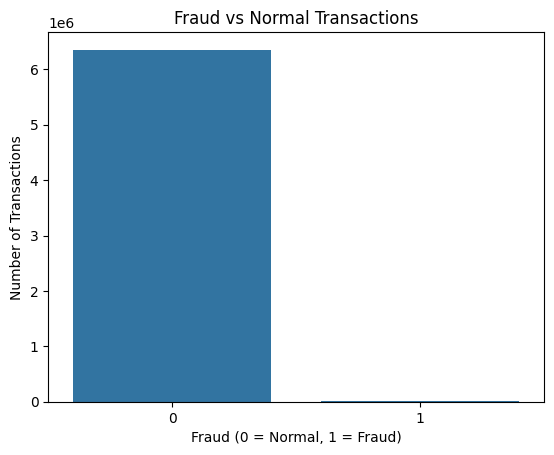

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count fraud and normal transactions

sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

In [19]:
# Count fraud transactions

fraud_count = df["isFraud"].sum()

print("Number of fraud transactions:", fraud_count)

Number of fraud transactions: 8213


In [20]:
# Compare transaction amount

print(df.groupby("isFraud")["amount"].mean())

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64


In [21]:
# Reload original dataset for pattern analysis

df_pattern = pd.read_csv(file_path)

# Display fraud by transaction type

print(
    pd.crosstab(
        df_pattern["type"],
        df_pattern["isFraud"]
    )
)

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


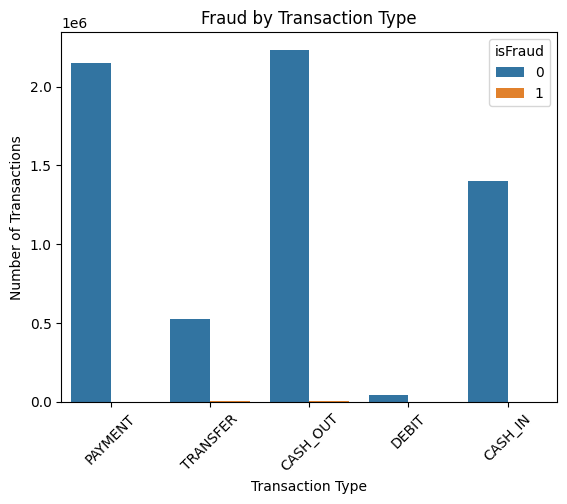

In [22]:
# Plot fraud by transaction type

sns.countplot(
    x="type",
    hue="isFraud",
    data=df_pattern
)

plt.title("Fraud by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

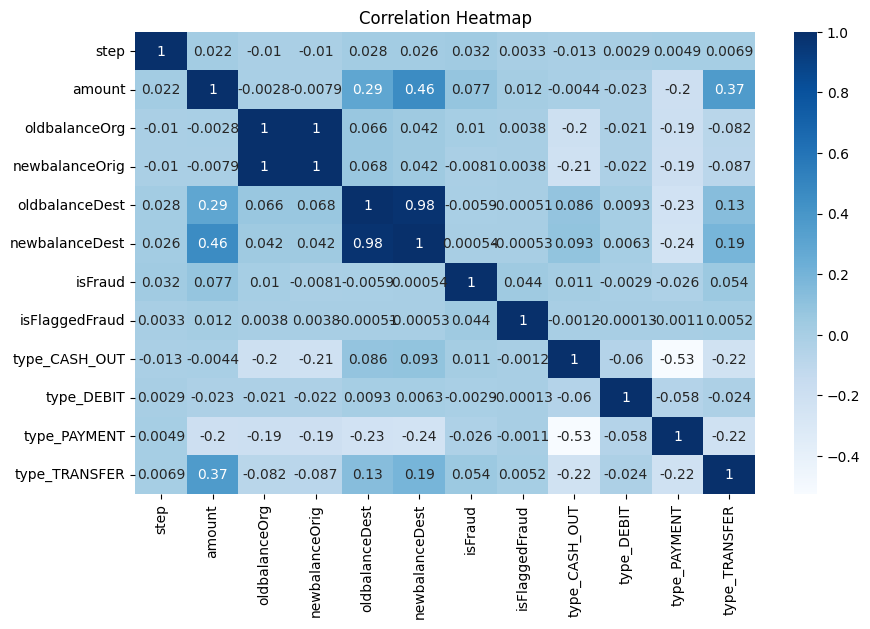

In [23]:
# Create correlation matrix

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

In [24]:
# Separate fraud and normal transactions

fraud_data = df[df["isFraud"] == 1]

normal_data = df[df["isFraud"] == 0]

print("Fraud transactions:", len(fraud_data))
print("Normal transactions:", len(normal_data))

Fraud transactions: 8213
Normal transactions: 6354407


In [25]:
# Take 100,000 normal transactions

normal_sample = normal_data.sample(
    n=100000,
    random_state=42
)

print("Normal sample:", len(normal_sample))

Normal sample: 100000


In [26]:
# Combine fraud and normal transactions

model_data = pd.concat(
    [fraud_data, normal_sample],
    axis=0
)

# Shuffle the data

model_data = model_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Model dataset shape:", model_data.shape)

Model dataset shape: (108213, 12)


In [27]:
# Separate features and target

X = model_data.drop("isFraud", axis=1)

y = model_data["isFraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (108213, 11)
y shape: (108213,)


In [28]:
from sklearn.model_selection import train_test_split

# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (86570, 11)
Testing data: (21643, 11)


In [29]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
isFraud
0    80000
1     6570
Name: count, dtype: int64

After SMOTE:
isFraud
0    80000
1    80000
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [31]:
# Create Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000
)

# Train the model

lr_model.fit(
    X_train_scaled,
    y_train_smote
)

# Make predictions

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression completed.")

Logistic Regression completed.


In [32]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model

rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Make predictions

rf_pred = rf_model.predict(X_test)

print("Random Forest completed.")

Random Forest completed.


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [34]:
# Logistic Regression evaluation

lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(y_test, lr_pred)

lr_recall = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)

lr_probability = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

lr_auc = roc_auc_score(
    y_test,
    lr_probability
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

Logistic Regression
-------------------
Accuracy : 0.9513468557963314
Precision: 0.6170634920634921
Recall   : 0.9464394400486914
F1 Score : 0.7470574105212587
ROC-AUC  : 0.9898459525258673


In [35]:
# Random Forest evaluation

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

rf_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Random Forest
-------------
Accuracy : 0.9956567943445918
Precision: 0.9542521994134897
Recall   : 0.9902617163724894
F1 Score : 0.9719235364396654
ROC-AUC  : 0.9994666159464393


In [36]:
# Compare models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.951347,0.617063,0.946439,0.747057,0.989846
1,Random Forest,0.995657,0.954252,0.990262,0.971924,0.999467


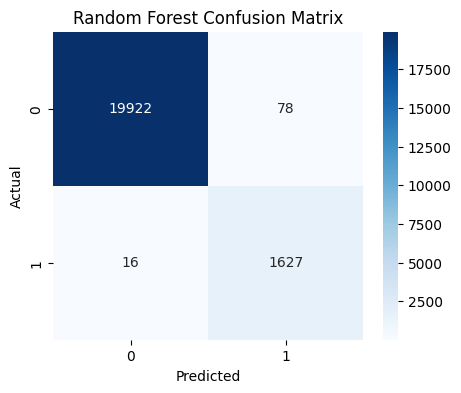

In [37]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

# Display confusion matrix

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
from sklearn.metrics import classification_report

# Detailed evaluation

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20000
           1       0.95      0.99      0.97      1643

    accuracy                           1.00     21643
   macro avg       0.98      0.99      0.98     21643
weighted avg       1.00      1.00      1.00     21643



In [39]:
# Get feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
2    oldbalanceOrg    0.316807
3   newbalanceOrig    0.170770
1           amount    0.148717
10   type_TRANSFER    0.090803
9     type_PAYMENT    0.063608
5   newbalanceDest    0.057116
0             step    0.053929
7    type_CASH_OUT    0.049375
4   oldbalanceDest    0.048472
8       type_DEBIT    0.000325
6   isFlaggedFraud    0.000079


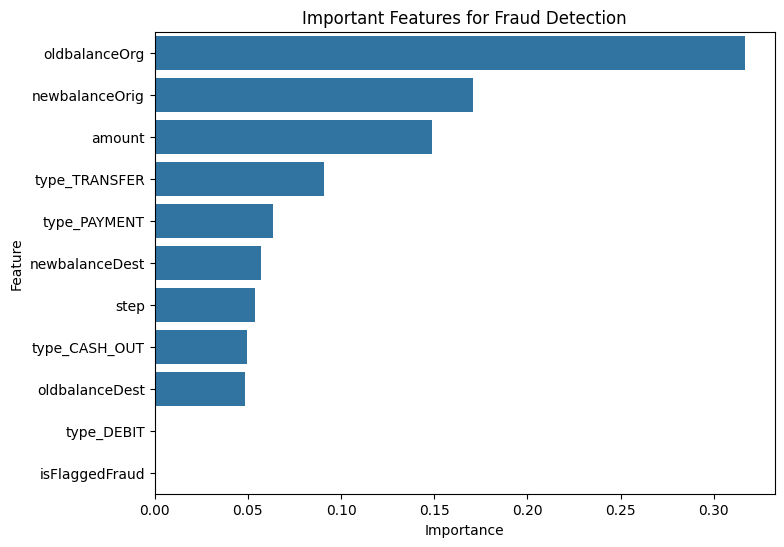

In [40]:
# Plot important features

plt.figure(figsize=(8, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Important Features for Fraud Detection")

plt.show()